In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_excel("/content/house_price_dataset.xlsx")

In [29]:
df.describe()

,House_Area_sqft,Bedrooms,Bathrooms,Location_Score,Age_of_Property,House_Price
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,2827.87200,3.481500,3.033500,5.493000,19.801500,2.146798e+07
std,1271.54565,1.719923,1.421052,2.809074,11.976636,8.338209e+06
min,601.00000,1.000000,1.000000,1.000000,0.000000,4.825449e+06
25%,1733.75000,2.000000,2.000000,3.000000,9.000000,1.430224e+07
50%,2823.50000,3.000000,3.000000,6.000000,19.000000,2.153332e+07
75%,3972.00000,5.000000,4.000000,8.000000,30.000000,2.884789e+07
max,5000.00000,6.000000,5.000000,10.000000,40.000000,3.790138e+07


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   House_Area_sqft  2000 non-null   int64
 1   Bedrooms         2000 non-null   int64
 2   Bathrooms        2000 non-null   int64
 3   Location_Score   2000 non-null   int64
 4   Age_of_Property  2000 non-null   int64
 5   House_Price      2000 non-null   int64
dtypes: int64(6)
memory usage: 93.9 KB


In [31]:
df.shape

(2000, 6)

In [32]:
#Identify Independent and Dependent Variables
X = df.drop("House_Price", axis=1)
y = df["House_Price"]
print("Independent Variables:")
print(X.head())
print("\nDependent Variable:")
print(y.head())

Independent Variables:
   House_Area_sqft  Bedrooms  Bathrooms  Location_Score  Age_of_Property
0             1512         1          3               4               14
1             1439         6          5               2               37
2              860         1          1               4               14
3              817         5          2               9               26
4             4279         5          3               1               10

Dependent Variable:
0    11524316
1    11995917
2     7169903
3     9591648
4    30556643
Name: House_Price, dtype: int64


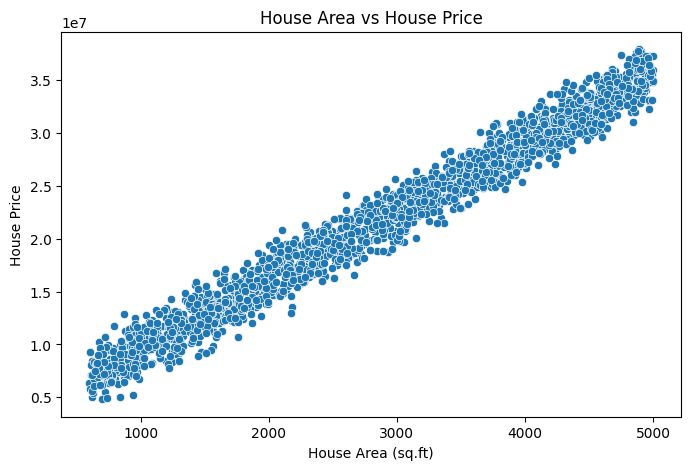

In [33]:
#House Area vs House Price
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["House_Area_sqft"],
    y=df["House_Price"])
plt.title("House Area vs House Price")
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price")
plt.show()

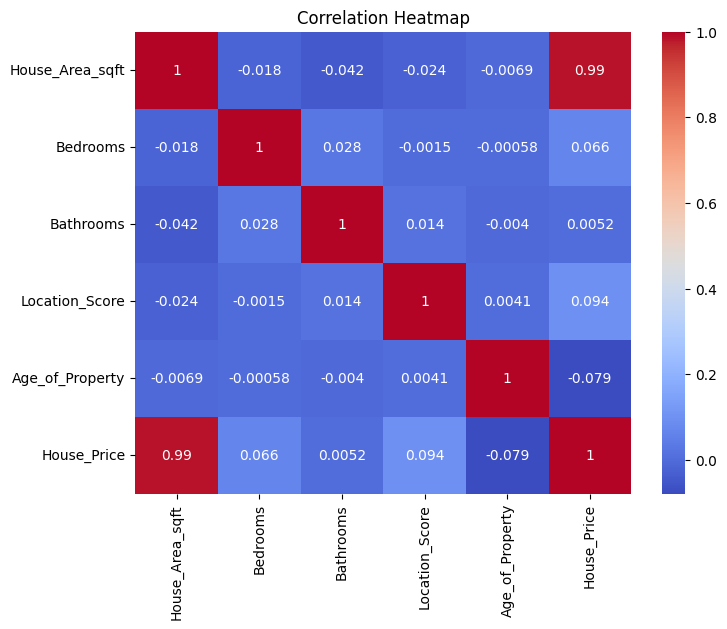

In [34]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [35]:
#Split Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 5)
Testing Data Shape: (400, 5)


In [36]:
#Select Feature
x = df[["House_Area_sqft"]]
y = df[["House_Price"]]

In [37]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [38]:
#Train the Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [39]:
#Make Predictions
y_pred = model.predict(X_test)

In [40]:
#Display Slope and Intercept
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): [  6501.63853531 398399.56912223 250645.08446653 351645.43682489
 -50582.37069261]
Intercept: [3928.08421297]


**Interpretation **
Slope: Indicates how much the house price changes for every additional square foot of house area.
Intercept: The predicted house price when the house area is 0 (used mathematically to define the regression line)

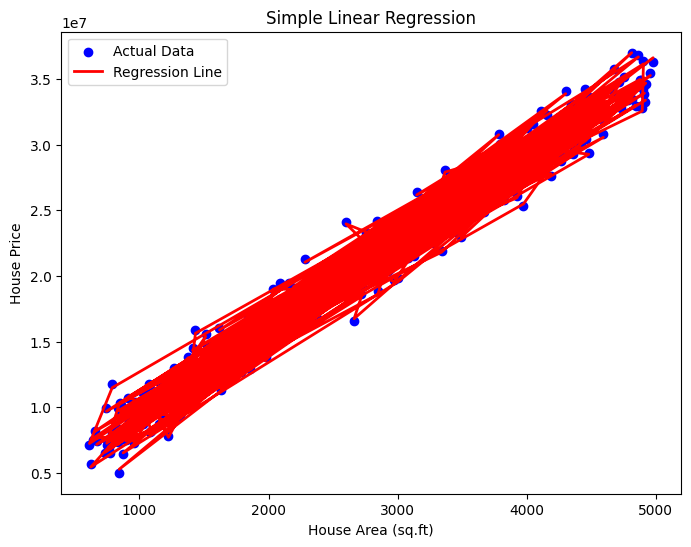

In [41]:
import matplotlib.pyplot as plt

#Plot the Regression Line
plt.figure(figsize=(8,6))
plt.scatter(
    X_test['House_Area_sqft'], # Select a single feature for x-axis
    y_test,
    color="blue",
    label="Actual Data")
plt.plot(
    X_test['House_Area_sqft'], # Select a single feature for x-axis
    y_pred,
    color="red",
    linewidth=2,
    label="Regression Line")
plt.title("Simple Linear Regression")
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price")
plt.legend()
plt.show()

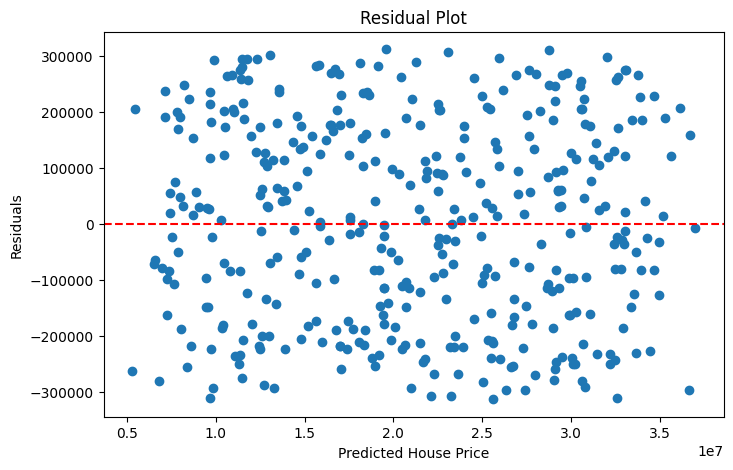

In [42]:
#Validate Linear Regression Assumptions
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(
    y_pred,
    residuals)
plt.axhline(
    y=0,
    color="red",
    linestyle="--")
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

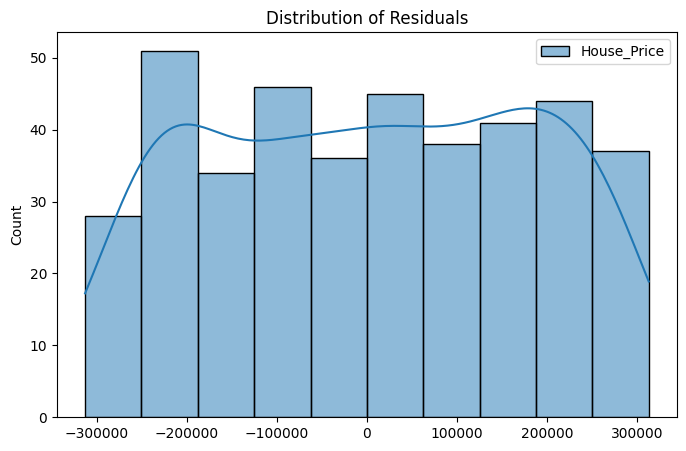

In [43]:
#Histogram of Residuals
plt.figure(figsize=(8,5))
sns.histplot(
    residuals,
    kde=True,
    color="skyblue")
plt.title("Distribution of Residuals")
plt.show()

In [44]:
#Import Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [45]:
#Calculate MAE, MSE, RMSE, and R²
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 154306.042345158
Mean Squared Error (MSE): 31545039379.95035
Root Mean Squared Error (RMSE): 177609.2322486372
R² Score: 0.9995362676110691


In [46]:
#Calculate Adjusted R²
n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
) / (n - p - 1)
print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.9995303826822756


In [47]:
#Select Independent and Dependent Variables
X = df.drop("House_Price", axis=1)
y = df["House_Price"]

In [48]:
#Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [49]:
#Train Multiple Linear Regression Model
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

In [50]:
#Predict House Prices
y_pred_multi = mlr.predict(X_test)

In [51]:
  #Display Coefficients
  coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": mlr.coef_})
coefficients

,Feature,Coefficient
0,House_Area_sqft,6501.638535
1,Bedrooms,398399.569122
2,Bathrooms,250645.084467
3,Location_Score,351645.436825
4,Age_of_Property,-50582.370693


In [52]:
#Evaluate the Model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred_multi)
mse = mean_squared_error(y_test, y_pred_multi)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_multi)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 154306.042345158
MSE : 31545039379.95035
RMSE : 177609.2322486372
R² Score : 0.9995362676110691


In [53]:
#Calculate Adjusted R²
n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
) / (n - p - 1)
print("Adjusted R² :", adjusted_r2)

Adjusted R² : 0.9995303826822756


In [54]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [55]:
X = df[["House_Area_sqft"]]
y = df["House_Price"]

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [57]:
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)
model2 = LinearRegression()
model2.fit(X_train_poly2, y_train)
y_pred_poly2 = model2.predict(X_test_poly2)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
print("Degree 2 Results")
print("MAE :", mean_absolute_error(y_test, y_pred_poly2))
print("MSE :", mean_squared_error(y_test, y_pred_poly2))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_poly2)))
print("R² :", r2_score(y_test, y_pred_poly2))

Degree 2 Results
MAE : 1122763.2401095035
MSE : 1907581690829.9026
RMSE : 1381152.3054427786
R² : 0.9719573209621137


In [60]:
poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)
model3 = LinearRegression()
model3.fit(X_train_poly3, y_train)
y_pred_poly3 = model3.predict(X_test_poly3)

print("Degree 3 Results")
print("MAE :", mean_absolute_error(y_test, y_pred_poly3))
print("MSE :", mean_squared_error(y_test, y_pred_poly3))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_poly3)))
print("R² :", r2_score(y_test, y_pred_poly3))

Degree 3 Results
MAE : 1122995.591700648
MSE : 1908452479873.545
RMSE : 1381467.5095251226
R² : 0.971944519802521


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


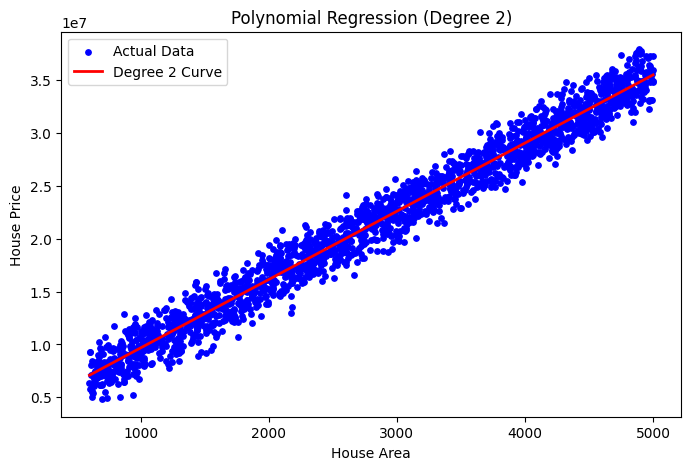

In [61]:
X_grid = np.linspace(
    X.min(),
    X.max(),
    100
).reshape(-1, 1)
plt.figure(figsize=(8,5))
plt.scatter(
    X,
    y,
    color="blue",
    s=15,
    label="Actual Data")
plt.plot(
    X_grid,
    model2.predict(poly2.transform(X_grid)),
    color="red",
    linewidth=2,
    label="Degree 2 Curve")
plt.title("Polynomial Regression (Degree 2)")
plt.xlabel("House Area")
plt.ylabel("House Price")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


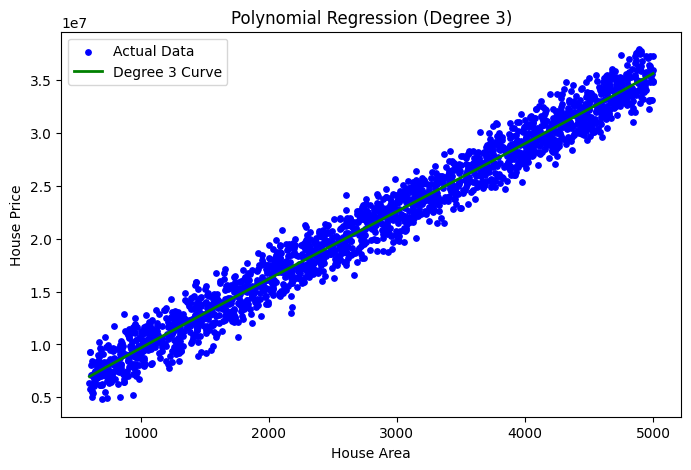

In [62]:
plt.figure(figsize=(8,5))
plt.scatter(
    X,
    y,
    color="blue",
    s=15,
    label="Actual Data")
plt.plot(
    X_grid,
    model3.predict(poly3.transform(X_grid)),
    color="green",
    linewidth=2,
    label="Degree 3 Curve")
plt.title("Polynomial Regression (Degree 3)")
plt.xlabel("House Area")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [63]:
from sklearn.preprocessing import StandardScaler
X = df[["House_Area_sqft"]]
y = df["House_Price"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
from sklearn.preprocessing import StandardScaler
X = df[["House_Area_sqft"]]
y = df["House_Price"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [65]:
from sklearn.linear_model import LinearRegression
batch_model = LinearRegression()
batch_model.fit(X_train, y_train)
batch_pred = batch_model.predict(X_test)

In [66]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
print("Batch Gradient Descent")
print("RMSE :", np.sqrt(mean_squared_error(y_test, batch_pred)))
print("R² :", r2_score(y_test, batch_pred))

Batch Gradient Descent
RMSE : 1381270.0064633808
R² : 0.9719525411958707


In [67]:
from sklearn.linear_model import SGDRegressor
sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate="constant",
    eta0=0.01,
    random_state=42)
sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)

In [68]:
print("Stochastic Gradient Descent")
print("RMSE :", np.sqrt(mean_squared_error(y_test, sgd_pred)))
print("R² :", r2_score(y_test, sgd_pred))

Stochastic Gradient Descent
RMSE : 9.77035402820249e+16
R² : -1.4033207833091465e+20


In [ ]:
from sklearn.linear_model import SGDRegressor
import numpy as np

mini_model = SGDRegressor(
    random_state=42,
    learning_rate="constant",
    eta0=0.01
)

batch_size = 32

for epoch in range(20):
    indices = np.random.permutation(len(X_train))

    X_train_shuffled = X_train.iloc[indices]
    y_train_shuffled = y_train.iloc[indices]

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled.iloc[i:i+batch_size]

        mini_model.partial_fit(X_batch, y_batch)

mini_pred = mini_model.predict(X_test)

## Conclusion

This project focused on predicting house prices using different regression techniques. Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression models were implemented and evaluated using MAE, MSE, RMSE, R² Score, and Adjusted R².

The performance of each model was compared to identify the most suitable model for house price prediction. Gradient Descent optimization techniques, including Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent, were also studied to understand how model parameters are optimized during training.

The project demonstrated the importance of selecting the appropriate regression model based on the dataset. It also highlighted the concepts of bias, variance, overfitting, and underfitting, which are essential for building reliable machine learning models.

Overall, the project provided practical experience in regression analysis, model evaluation, optimization techniques, and predictive analytics using Python.
